<h1>Выпускной проект: "БАНКИ - анализ оттока клиентов"</h1>

<b> Описание: </b>  
Заказчик - отдел маркетинга "Метанпромбанка" заметил, что в банке повысился отток клиентов. Нужно понять почему так? Ранее было проведено исследование оттока, составлены дэшборды и выделены сегменты, но клиентсаая база поменялась, и текущие решения не работают. Региональный банк располагается в Ярославле и областных городах: Ростов Великий и Рыбинск. Отдел маркетинга предоставил данные о клиентах "Метанпромбанка" в файле <i>bank_scrooge.csv</i>.

<b> Предоставленные данные: </b> 
    
+ USERID — идентификатор пользователя;  
+ score — баллы кредитного скоринга;  
+ city — город;  
+ gender — пол;  
+ age — возраст;  
+ equity - количество баллов собственности;  
+ balance — баланс на счете;   
+ products — количество продуктов, которыми пользуется клиент;  
+ credit_card — имеется ли кредитная карта (0 - не имеется, 1 - имеется);  
+ last_activity — активный клиент (p.s. если клиент пользуется приложением в течение 30 дней - он активный; если не пользуется более 90 дней - считается отточный);  
+ EST_SALARY — оценочный доход клиента;  
+ churn — признак оттока (0 - остался, 1 - ушел).

<b> Задача: </b>  
Проанализировать клиентов регионального банка "Метанпромбанк" и выделить сегменты клиентов, склонных уходить из банка.

<h1>ОПИСАНИЕ: </h1>

   [1. Загрузка, обзор и анализ предоставленных данных.](#1)  
       [1.1. Промежуточный вывод.](#1.1)  
    
   [2. Подготовка данных для дальнейшего исследования.](#2)  
       [2.1. Изменение стиля заголовков.](#2.1)   
       [2.2. Обработка пропусков.](#2.2)  
       [2.3. Преобразование данных к нужным типам.](#2.3)  
       [2.4. Проверка данных на дубликаты.](#2.4)      
       [2.5. Промежуточные выводы.](#2.5)  
        
   [3. Исследовательский анализ данных (EDA).](#3)  
       [3.1. Анализ распределения признаков, в том числе в разрезе оттока.](#3.1)    
       [3.2. Корреляционный анализ.](#3.2)    
       [3.3. Составление и проверка гипотез.](#3.3)  
               [3.3.1. Гипотеза 1: Среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших клиентов равно.](#3.3.1)   
               [3.3.2. Гипотеза 2: Распределение пола среди ушедших и оставшихся клиентов независимо.](#3.3.2)  
       [3.4. Промежуточные выводы.](#3.4)  
                   
   [4. Сегментация отточных клиентов банка.](#4)  
       [4.1. Приортизация сегментов клиентов банка.](#4.1)
       
   [5. Заключительный вывод. Рекомендации.](#5)  
        [5.1. Ссылка на презентацию.](#5.1) 

<h1>1. Загрузка, обзор и анализ предоставленных данных.</h1>
<a id='1'></a>

In [1]:
# импорт библиотек: 
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
import math
import scipy.stats as st
from scipy.stats import chi2_contingency

In [2]:
# загрузим файл
bank = pd.read_csv('https://code.s3.yandex.net/datasets/bank_scrooge.csv')

In [3]:
# настроим полный вывод данных для удобства
pd.options.display.max_columns = None # столбцы без ограничений
pd.options.display.max_rows = None # строки без ограничений
pd.options.display.max_colwidth = None # ширина столбцов без ограничений
pd.options.display.float_format = '{:.2f}'.format # числа с плавающей точкой отображаются с 2-мя знаками после запятой

In [4]:
# добавим функцию для оптимизации
def check_df (df):
    display(df.info()) # общая информация 
    display(df.head()) # первые 5 строк
    display(df.describe()) # сводка по числовым колонкам

In [5]:
check_df(bank)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   USERID         10000 non-null  int64  
 1   score          10000 non-null  float64
 2   city           10000 non-null  object 
 3   gender         10000 non-null  object 
 4   age            9974 non-null   float64
 5   equity         10000 non-null  int64  
 6   balance        7705 non-null   float64
 7   products       10000 non-null  int64  
 8   credit_card    10000 non-null  int64  
 9   last_activity  10000 non-null  int64  
 10  EST_SALARY     10000 non-null  float64
 11  churn          10000 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 937.6+ KB


None

,USERID,score,city,gender,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
0,183012,850.00,Рыбинск,Ж,25.00,1,59214.82,2,0,1,75719.14,1
1,146556,861.00,Рыбинск,Ж,37.00,5,850594.33,3,1,0,86621.77,0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,107683.34,0
3,225363,866.00,Ярославль,Ж,51.00,5,1524746.26,2,0,1,174423.53,1
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,67353.16,1


,USERID,score,age,equity,balance,products,credit_card,last_activity,EST_SALARY,churn
count,10000.00,10000.00,9974.00,10000.00,7705.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,171814.71,848.70,42.73,2.63,827794.31,1.87,0.68,0.52,147866.89,0.18
std,33708.24,65.45,12.18,1.98,1980614.15,0.79,0.47,0.50,139388.51,0.39
min,94561.00,642.00,18.00,0.00,0.00,0.00,0.00,0.00,2546.30,0.00
25%,142810.25,802.00,33.00,0.00,295554.16,1.00,0.00,0.00,75251.90,0.00
50%,172728.00,853.00,40.00,3.00,524272.20,2.00,1.00,1.00,119658.10,0.00
75%,201261.75,900.00,51.00,4.00,980705.85,2.00,1.00,1.00,174500.54,0.00
max,229145.00,1000.00,86.00,9.00,119113552.01,5.00,1.00,1.00,1395064.45,1.00


<b>1.1. Промежуточный вывод.</b>
<a id='1.1'></a>

Получили данные о клиентах регионального банка "Метанпромбанк" в файле "bank_scrooge.csv".  
Загрузили файл в датасет "bank".  
Данные представляют собой таблицу из 10.000 строк и 12 стобцов:  
1. Идентификатор пользователя;  
2. Баллы кредитного скорринга;  
3. Город проживания клиента;  
4. Пол клиента;  
5. Возраст клиента;  
6. Количество баллов собственности клиента;  
7. Баланс счета клиента;  
8. Количество продуктов, которыми пользуется клиент;  
9. Наличие кредитной карты у клиента;  
10. Активность клиента;  
11. Оценочный доход клиента (зарабатная плата);  
12. Признак оттока.  

Обнаружили проблемы со стилизацией столбцов таблицы, наличие пропусков в столбцах возраста и баллов кредитного скоринга, непорядок с типом данных в столбцах баллов кредитного скорринга и возраста.  
Отмечаем, что значения в столбцах о наличии кредитной карты у клиента, активности клиента и признаке оттока представлены в бинарном виде, то есть 1 - характерно для клиента, 0 - не характерно.  

<h1>2. Подготовка данных для дальнейшего исследования.</h1>
<a id='2'></a>

<b>2.1. Изменение стиля заголовков.</b>
<a id='2.1'></a>

In [6]:
# приведем названия столбцов к нижнему регистру и уберем лишние пробелы
bank.columns = bank.columns.str.lower().str.strip()

In [7]:
# проверим
bank.columns

Index(['userid', 'score', 'city', 'gender', 'age', 'equity', 'balance',
       'products', 'credit_card', 'last_activity', 'est_salary', 'churn'],
      dtype='object')

<b>2.2. Обработка пропусков.</b>
<a id='2.2'></a>

In [8]:
# сначала уберем из таблицы строки с клиентами, у которых нет ни одного продукта банка 
# могли не удалиться из системы, но банком уже не пользоваться
bank = bank[bank['products']!=0]

In [9]:
# посмотрим на количество пропусков по столбцам
bank.isnull().sum()

userid              0
score               0
city                0
gender              0
age                26
equity              0
balance          2294
products            0
credit_card         0
last_activity       0
est_salary          0
churn               0
dtype: int64

In [10]:
# теперь в процентном содержании
bank.isnull().mean() * 100

userid           0.00
score            0.00
city             0.00
gender           0.00
age              0.26
equity           0.00
balance         22.94
products         0.00
credit_card      0.00
last_activity    0.00
est_salary       0.00
churn            0.00
dtype: float64

<i>пропуски имеются в столбцах возраст в количестве 26 шт. (0.26% от общего числа строк) и баланс на счете в количестве 2.294 шт. (22.94% от общего числа строк).</i>

In [11]:
# сначала посомтрим на пропуски в столбце возраста клиентов
bank[bank['age'].isna()]

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn
1247,228075,932.00,Ярославль,М,NaN,5,7601719.20,2,1,1,408121.16,0
2165,187635,692.00,Рыбинск,Ж,NaN,0,NaN,1,1,1,160368.82,0
2444,221156,913.00,Ярославль,М,NaN,0,NaN,1,1,1,135693.24,0
3091,138660,836.00,Ростов,Ж,NaN,5,294315.53,2,0,1,63310.22,1
4912,210674,834.00,Рыбинск,М,NaN,1,238330.52,2,0,1,93775.06,0
5470,218868,827.00,Рыбинск,Ж,NaN,4,448959.07,2,1,1,67835.95,0
5495,151662,884.00,Рыбинск,Ж,NaN,0,NaN,1,1,1,137500.77,0
7236,210135,908.00,Рыбинск,Ж,NaN,4,1120340.31,3,1,1,85002.15,0
7248,219343,920.00,Рыбинск,Ж,NaN,0,NaN,1,1,0,159248.67,0
7345,184913,829.00,Ярославль,Ж,NaN,3,188648.77,2,0,1,75206.90,0


<i> Пропусков в столбце возраста клиентов не так много, всего 26, что составляет 0.26% от общего числа строк в данном столбце. Они не связаны с какой-либо конкретной характеристикой. Такие пропуски можно отнести к MCAR по общепринятой классификации пропусков.  
    
    MCAR (Missing Completely At Random / Отсутствует совершенно случайно) — пропуски не зависят от переменных и не ведут к   систематической ошибке (смещение, bias), но увеличивают случайную ошибку (разброс, variance), можно их отбрасывать или   заполнять, т.к. заполнение не повлияет на характер связи между заполняемой переменной и остальными.  
    
Отбрасывать их не будем, лучше заполним эти пропуски медианными значениями. </i>

In [12]:
# заполним пропуски медианными значениями
bank['age'] = bank['age'].fillna(bank['age'].median())

In [13]:
# проверим
bank['age'].isnull().sum()

0

In [14]:
# теперь разберемся со столбцом баланса
# зададим функцию для подсчета количества пропусков внутри каждой категории
def omissions(group):
    return group['balance'].isna().sum()

# выведем зависимость в процентах для категориальных значений
features = ['equity','products', 'credit_card', 'last_activity', 'churn']

for feature in features:
    print(f"\nКоличество пропусков в 'balance' от {feature}:")
    count = bank.groupby(feature).apply(omissions)
    print(count)


Количество пропусков в 'balance' от equity:
equity
0    2180
1     114
2       0
3       0
4       0
5       0
6       0
7       0
8       0
9       0
dtype: int64

Количество пропусков в 'balance' от products:
products
1    1950
2     315
3      29
4       0
5       0
dtype: int64

Количество пропусков в 'balance' от credit_card:
credit_card
0     422
1    1872
dtype: int64

Количество пропусков в 'balance' от last_activity:
last_activity
0    1033
1    1261
dtype: int64

Количество пропусков в 'balance' от churn:
churn
0    2282
1      12
dtype: int64


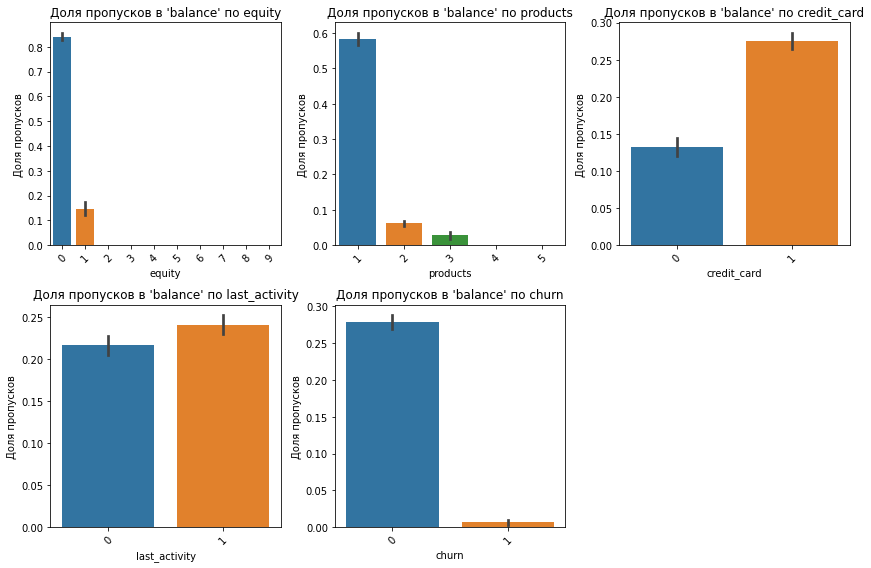

In [15]:
# визуализируем полученные данные по долям
# определим параметры сетки
num_features = len(features) # количество наших признаков
n_cols = 3 # количество столбцов
n_rows = math.ceil(num_features / n_cols) # вычисляем количество строк

# зададим фигуру
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

# создадим столбец с флагом пропусков
bank['missing_balance'] = bank['balance'].isna().astype(int)

# построим график в цикле
for i, feature in enumerate(features):
    row_idx = i // n_cols
    col_idx = i % n_cols
    ax = axes[row_idx][col_idx]
    sns.barplot(x=feature, y='missing_balance', data=bank, ax=ax)
    ax.set_title(f"Доля пропусков в 'balance' по {feature}")
    ax.set_ylabel('Доля пропусков')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

# удалим пустые графики
for j in range(i + 1, n_rows * n_cols):
    row_idx = j // n_cols
    col_idx = j % n_cols
    fig.delaxes(axes[row_idx][col_idx])

# отображаем
    plt.tight_layout()
plt.show()

<i>Получили, что пропущенные значения в столбце баланса в основном у клиентов:  

+ с отсутствием баллов собственности;  
+ с одним продуктом банка;  
+ имеющих кредитные карты;  
+ активных;  
+ неотточных.  
    
Пока нельзя в целом понять, важно для нас это или нет. Работаем дальше.</i> 

In [16]:
# поработаем через one-hot кодирование
# категориальные переменные преобразуем в бинарные столбцы
bank['city_']=bank['city']
bank['gender_']=bank['gender']
bank = pd.get_dummies(bank, columns = ['city_', 'gender_'])
bank = bank.rename(
columns = ({
'city__Ростов':'rostov', 'city__Рыбинск':'rybinsk','city__Ярославль':'yaroslavl',
'gender__Ж':'female', 'gender__М':'male'}))
bank.head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
0,183012,850.00,Рыбинск,Ж,25.00,1,59214.82,2,0,1,75719.14,1,0,0,1,0,1,0
1,146556,861.00,Рыбинск,Ж,37.00,5,850594.33,3,1,0,86621.77,0,0,0,1,0,1,0
2,120722,892.00,Рыбинск,Ж,30.00,0,NaN,1,1,1,107683.34,0,1,0,1,0,1,0
3,225363,866.00,Ярославль,Ж,51.00,5,1524746.26,2,0,1,174423.53,1,0,0,0,1,1,0
4,157978,730.00,Ярославль,М,34.00,5,174.00,1,1,0,67353.16,1,0,0,0,1,0,1


In [17]:
# посчитаем матрицу корреляции
corr_matrix = bank.corr()
corr_matrix

,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
userid,1.00,0.01,0.02,0.00,0.01,-0.00,0.01,-0.03,-0.00,-0.01,0.00,-0.03,0.01,0.01,-0.03,0.03
score,0.01,1.00,-0.01,0.06,0.24,-0.00,-0.09,-0.03,0.16,0.11,0.14,-0.04,-0.00,0.03,-0.01,0.01
age,0.02,-0.01,1.00,0.02,0.07,0.02,-0.12,-0.01,-0.04,-0.05,-0.03,0.05,0.03,-0.06,0.21,-0.21
equity,0.00,0.06,0.02,1.00,0.16,0.43,-0.17,-0.00,-0.17,0.27,-0.71,0.04,-0.01,-0.02,0.02,-0.02
balance,0.01,0.24,0.07,0.16,1.00,0.08,-0.06,0.03,0.34,0.09,NaN,-0.04,-0.03,0.06,-0.05,0.05
products,-0.00,-0.00,0.02,0.43,0.08,1.00,-0.25,0.04,-0.12,0.30,-0.49,-0.01,-0.04,0.04,0.02,-0.02
credit_card,0.01,-0.09,-0.12,-0.17,-0.06,-0.25,1.00,-0.03,0.04,-0.13,0.16,-0.10,-0.05,0.11,-0.13,0.13
last_activity,-0.03,-0.03,-0.01,-0.00,0.03,0.04,-0.03,1.00,0.00,0.17,0.03,0.01,0.05,-0.05,0.01,-0.01
est_salary,-0.00,0.16,-0.04,-0.17,0.34,-0.12,0.04,0.00,1.00,0.00,0.31,-0.11,-0.06,0.13,-0.08,0.08
churn,-0.01,0.11,-0.05,0.27,0.09,0.30,-0.13,0.17,0.00,1.00,-0.25,0.01,-0.03,0.02,-0.14,0.14


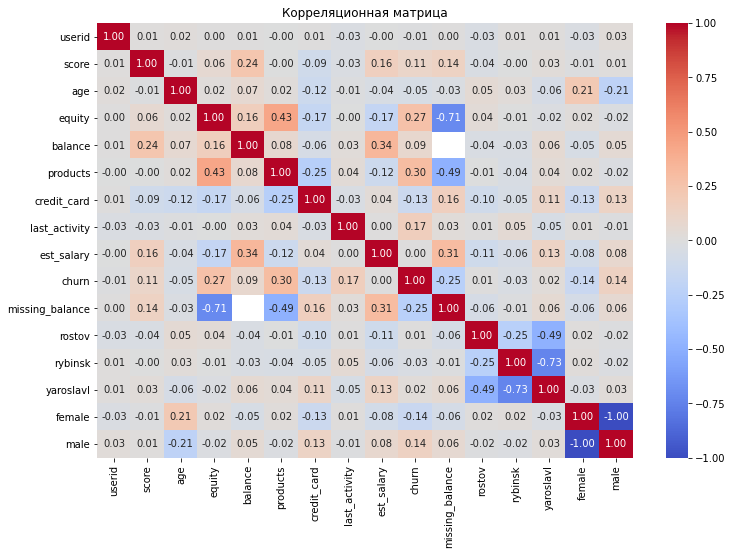

In [18]:
# построим тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show() 

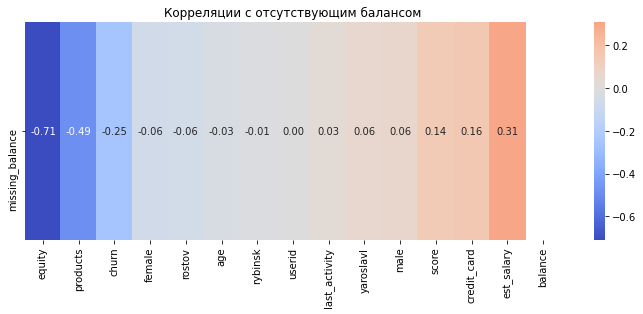

In [19]:
# строим тепловую карту корреляции с отсутствующим балансом, исключая саму переменную
corr_series = corr_matrix['missing_balance'].drop('missing_balance')
sorted_corr = corr_series.sort_values() # отсортируем по возрастанию

sorted_corr_df = sorted_corr.to_frame().T # фрейм для тепловой карты

plt.figure(figsize=(12, 4))

sns.heatmap(
    sorted_corr_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)

plt.title("Корреляции с отсутствующим балансом")
plt.show()

<i> Наблюдаем высокую отрицательную корреляцию (-0.71) между отсутствием баланса и баллами собственности. Может быть связана с тем, что при покупке собственности баланс клиента обнулился.  
        Также относительно высокая отрицательная корреляция (-0.49) отсутствия баланса на счету наблюдается с количеством продуктов банка, которыми пользуется клиент. Также можно обосновать покупкой крупного имущества (движимого и недвижимого).  
        Отмечаем, что отсутствие баланса не связанно с оттоком клиентов, корреляция отрицательная (-0.25).  
        Видим положительную корреляцию (0.31) между оценочным доходом клиента (его заработной платы) и отсутствием баланса, что в принципе логично.</i>.    

<i>Можно сделать вывод, что пропуски в балансе на счете клиентов можно отнести к MNAR по общепринятой классификации пропусков.

MNAR (Missing Not At Random / Отсутствует не случайно) — пропуски зависят от данных, без дополнительного обоснования их нельзя отбрасывать или заполнять одним значением, т.к. это приведёт к заметным искажениям.

<b>2.3. Преобразование данных к нужным типам.</b>
<a id='2.3'></a>

In [20]:
# поменяем типы данных в столбцах баллов кредитного скоринга и возраста
bank['score'] = bank['score'].astype('int') # меняем на целочисленные значения
bank['age'] = bank['age'].astype('int') # меняем на целочисленные значения

In [21]:
# проверяем
bank.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9999 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   userid           9999 non-null   int64  
 1   score            9999 non-null   int64  
 2   city             9999 non-null   object 
 3   gender           9999 non-null   object 
 4   age              9999 non-null   int64  
 5   equity           9999 non-null   int64  
 6   balance          7705 non-null   float64
 7   products         9999 non-null   int64  
 8   credit_card      9999 non-null   int64  
 9   last_activity    9999 non-null   int64  
 10  est_salary       9999 non-null   float64
 11  churn            9999 non-null   int64  
 12  missing_balance  9999 non-null   int64  
 13  rostov           9999 non-null   uint8  
 14  rybinsk          9999 non-null   uint8  
 15  yaroslavl        9999 non-null   uint8  
 16  female           9999 non-null   uint8  
 17  male          

<b>2.4. Проверка данных на дубликаты.</b>
<a id='2.4'></a>

In [22]:
# посмотрим явные дубликаты
bank.duplicated().sum()

0

<i>Явных дубликатов у нас не оказалось.  
Проверим неявные дубликаты по столбцу идентификатора пользователя.</i>

In [23]:
bank['userid'].duplicated().sum()

73

In [24]:
bank[bank['userid'].duplicated(keep=False)].head()

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
7,218868,825,Ярославль,Ж,38,4,458145.40,2,1,1,68085.48,0,0,0,0,1,1,0
58,164676,860,Ярославль,М,37,5,648594.03,2,1,1,213586.86,1,0,0,0,1,0,1
150,185748,850,Рыбинск,М,36,5,1203376.67,2,0,1,89401.82,1,0,0,1,0,0,1
161,197364,928,Рыбинск,Ж,53,6,1347183.86,2,0,1,168189.49,1,0,0,1,0,1,0
231,190253,823,Рыбинск,М,37,4,373348.39,2,0,1,131947.92,1,0,0,1,0,0,1


In [25]:
# добавим еще характеристик, чтобы потробнее изучить дубликаты, например добавим пол и возраст клиента
bank[bank.duplicated(['userid', 'gender', 'age'], False)]

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
3274,155765,863,Ярославль,М,30,5,1036114.50,5,1,1,150744.50,1,0,0,0,1,0,1
3668,185829,925,Рыбинск,М,40,0,NaN,1,1,0,228305.64,0,1,0,1,0,0,1
5197,155765,923,Рыбинск,М,30,0,NaN,1,1,1,120296.60,0,1,0,1,0,0,1
8205,227795,840,Рыбинск,М,34,2,350768.03,1,1,0,102036.14,1,0,0,1,0,0,1
8497,227795,839,Ярославль,М,34,2,326593.14,2,1,0,103314.92,0,0,0,0,1,0,1
9632,185829,927,Ярославль,М,40,0,NaN,1,1,0,231254.86,0,1,0,0,1,0,1


<i>Замечаем, что клиенты с одинаковыми идентификаторам, полом и возрастом с разных городов. Следует проверить по городам.</i>

In [26]:
bank.duplicated(subset=['userid', 'city']).sum()

0

<i>Дубликатов по столбцам идентификатора пользователя и городу не выявлено.  
    Значит, наши 73 дубликата можно обосновать неверным сбором данных. В разных городах присвоили разным клиентам банка одинаковый номер. От таких дубликатов нам избавляться нельзя.</i>

<b>2.5. Промежуточные выводы.</b>
<a id='2.5'></a>

Данные подготовлены для проведения дальнейшего исслендования.  
Что мы сделали:  
1. Названия столбцов привели к нижнему регистру и убрали все лишние пробелы и знаки;


2. Разобрались с пропусками. Пропуски имелись в 2-х столбцах нашей таблицы: возраст и оценочный доход клиента (его зарабатная плата):  
+ пропуски в столбце возраста мы заполнили медианными значениями (пропуски относятся к MCAR);  
+ пропуски в столбце оценочного дохода мы оставили без изменений (пропуски относятся к MNAR).  

3. Привели столбцы баллов кредитного скоринга и возраст к целочисленному типу данных;  


4. Проверили наши данные на дубликаты. Обнаружили 73 неявных дубликата в столбце идентификатор клиента, их не убирали, так как эти дубликаты могли возникнуть при не правильному сборе информации, но все эти клиенты есть и все они разные.

<h1>3. Исследовательский анализ данных (EDA).</h1>
<a id='3'></a>

<b>3.1. Анализ распределения признаков, в том числе в разрезе оттока.</b>
<a id='3.1'></a>

In [27]:
# посмотрим отточных клиентов в процентном эквиваленте
round(bank['churn'].mean() * 100, 2)

18.19

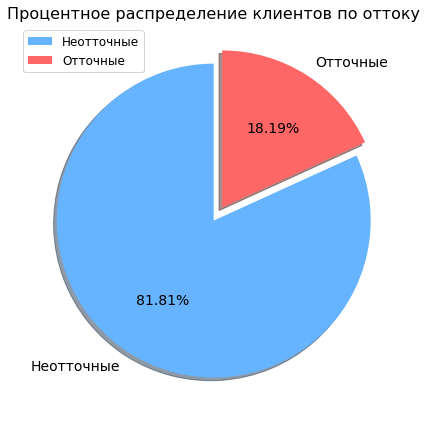

In [28]:
# визуализируем с помощью круговой диаграммы
churn_counts = bank['churn'].value_counts()

labels = ['Неотточные', 'Отточные']
sizes = [churn_counts[0], churn_counts[1]]
colors = ['#66b3ff', '#ff6666']
explode = (0, 0.1)

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90,
        colors=colors, explode=explode, shadow=True, textprops={'fontsize': 14})

plt.title('Процентное распределение клиентов по оттоку', fontsize=16)
plt.legend(labels, loc='best', fontsize=12)
plt.tight_layout()
plt.show()

<i> Процент отточных клиентов достаточно велик и составляет 18.19% от общего числа клиентов.</i>

In [29]:
bank_churn = bank.groupby('churn').agg({
    'equity': 'mean',
    'products': 'mean', 
    'credit_card': 'mean', 
    'last_activity': 'mean', 
    'female': 'mean', 
    'male': 'mean', 
    'score' : 'median', 
    'age': 'median', 
    'balance': 'median',
    'est_salary': 'median',                         
    'rostov': 'mean', 
    'rybinsk': 'mean', 
    'yaroslavl': 'mean',
}).rename(columns={'churn':'count'})

counts = bank['churn'].value_counts().sort_index()

result = pd.DataFrame({
    'Неотточные': bank_churn.iloc[0],
    'Отточные': bank_churn.iloc[1],
})

result['Относительная разница'] = (result['Отточные'] / result['Неотточные'] - 1)

# Сортируем по разнице
result_sorted = result.sort_values('Относительная разница', ascending=False)
result_sorted

,Неотточные,Отточные,Относительная разница
balance,475382.45,782410.47,0.65
equity,2.37,3.76,0.59
last_activity,0.48,0.70,0.45
male,0.47,0.65,0.39
products,1.76,2.38,0.35
est_salary,118257.71,125395.22,0.06
yaroslavl,0.58,0.61,0.05
rostov,0.14,0.15,0.04
score,848.00,866.00,0.02
age,40.00,39.00,-0.03


<i> Проанализируем по признакам:  
+ баланс на счете - у отточных клиентов больше, чем у неотточных (относительная разница 0.65);  
+ баллы собственности - у отточных клиентов больше, чем у неотточных (относительная разница 0.59);  
+ активность - по последним 90 дня отточные клиенты более активны, чем неотточные (относительная разница 0.45);
+ мужчины - больше отточных, чем неотточных (относительная разница 0.39);     
+ продукты банка - больше пользуются отточные клиенты )относительная разница (0.39);  
+ заработная плата - у отточных выше, чем у неотточных (относительная разница (0.06); 
+ г. Ярославль - больше отточных, чем неотточных (относительная разница 0.05);
+ г. Ростов - больше отточных, чем неотточных (относительная разница 0.39);    
+ баллы кредитного скоринга - выше у отточных, чем у неотточных (0.02);  
+ возраст - средний возраст у отточных 39 лет, у неотточных - 40 лет (относительная разница -0.03);  
+ г. Рыбинск - неотточных больше, чем отточных (относительная разница -0.13).
+ наличие кредитных карт - неотточные больше пользуются картами, нежели отточные (относительная разница -0.22);  
+ женщины - неотточных больше чем отточных (относительная разница (-0.34). </i>
  
 


In [30]:
# зададим функцию для визуализации непрерывных величин (баллы кредитного скоринга, возраст)
def plot_continuous_distribution(bank, feature, binwidth=1, figsize=(15,6)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # сначала общее распределение
    sns.histplot(data=bank, x=feature,
                 stat='density', common_norm=False,
                 color='green', alpha=0.5,  
                 label='Общее', binwidth=binwidth, ax=axes[0], kde=True)
    axes[0].set_title(f'Общее распределение {feature}')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('Плотность')
    axes[0].legend()
    axes[0].grid(True)

    # распределение по оттоку
    sns.histplot(data=bank[bank['churn']==1], x=feature,
                 stat='density', common_norm=False,
                 color='red', alpha=0.5,
                 label='Отточные', binwidth=binwidth, ax=axes[1], kde=True)
    sns.histplot(data=bank[bank['churn']==0], x=feature,
                 stat='density', common_norm=False,
                 color='blue', alpha=0.5,
                 label='Неотточные', binwidth=binwidth, ax=axes[1], kde=True)
    axes[1].set_title(f'Уровень {feature} по оттоку')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('Плотность')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

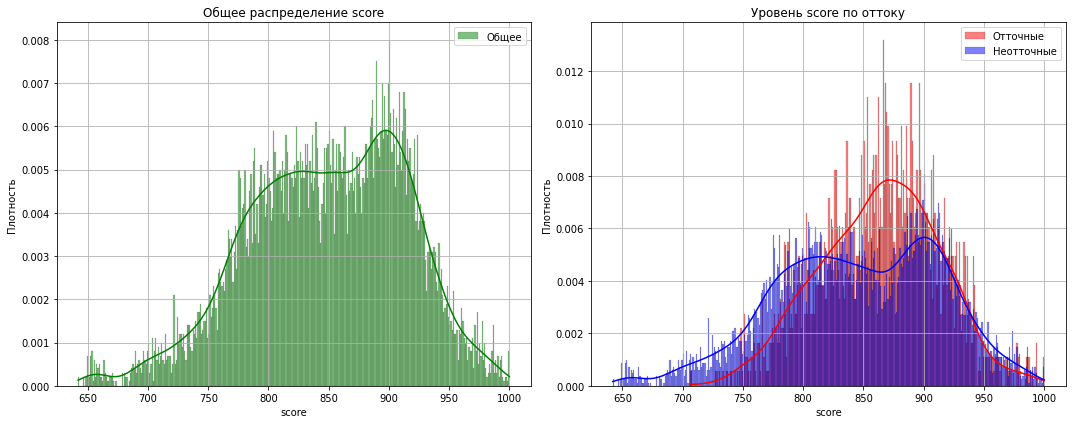

In [31]:
plot_continuous_distribution(bank, 'score')

<i> По распределению общего балла кредитного скоринга можно сказать, что большинство клиентов имеют баллы в диапазоне примерно от 700 до 950 баллов кредитного скоринга. Пик приходится на 800-900 баллов. Значит большинство клиентов имеют высокий уровень кредитного скоринга.  
    По распределению уровня баллов кредитного скоринга по отточности/неотточности видим, что клиенты с низкими (примерно до 730) баллами кредитного скоринга чаще совершают уход из банка, в то время как клиенты с более высокими (выше 800) баллами реже покидают банк, значит имеют для нас положительный исход. Также неотточные клиенты из этого диапазона немного проседают примерно в 870 баллах.   
    Однако заметим, что в диапазоне примерно от 820 до 900 баллов преобладают все-таки отточные клиенты.  
    Стоит обратить внимание, что распределение по отточности/неотточности смещено влево, то есть в сторону низких баллов кредитного скоринга, значит надо уделить внимание таким клиентам для снижения риска потерь.</i>

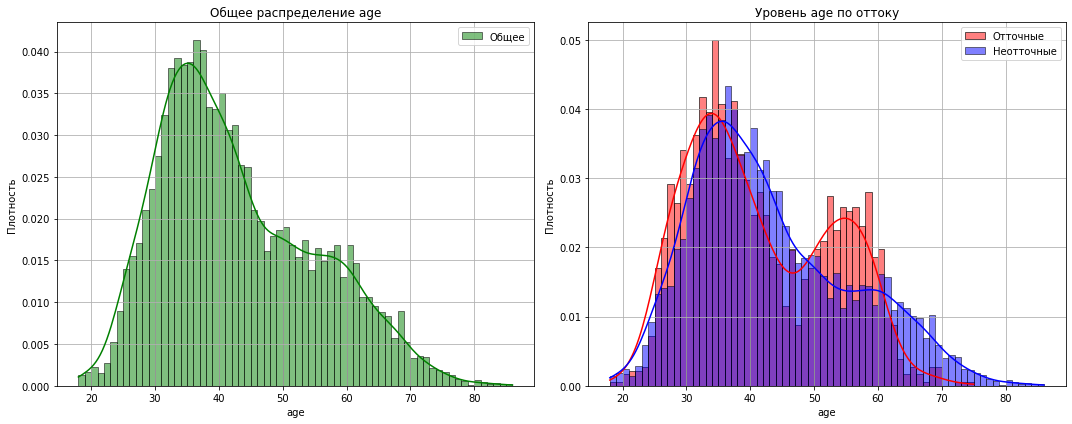

In [32]:
plot_continuous_distribution(bank, 'age')

<i> По общему распределению возрастов клиентов видим, что большинство клиентов банка в возрасте от 25 до 50 лет. Пик приходится на возраст в диапозоне от 30 до 40 лет. Значит основная часть клиентов - это молодые и средневозрастные люди, что естественно.  
    По графику отточности/неоточности видим, что у отточных клиентов банка по возрасту 2 пика: от 30 до 40 лет и от 50 до 60 лет. У неотточных также 2 пика: от 30 до 40 лет и около 60 лет.  
    Отметим, что у клиентов примерно до 25 лет и старше 60 лет низкий уровень отточности.</i>

In [33]:
# для оценочного дохода и баланса (из-за больших величин) зададим другую функцию
def plot_feature_distributions(bank, feature, figsize=(16, 4)):
    # общее распределение
    plt.figure(figsize=figsize)
    sns.kdeplot(bank[feature], clip=(0.0, 10000000.0), color='green', label='Общее')
    plt.title(f'Общее распределение {feature}')
    plt.ylabel('Плотность')
    plt.grid(True)
    plt.show()

    # распределение по оттоку
    plt.figure(figsize=figsize)
    sns.kdeplot(bank.loc[bank['churn'] == 1, feature], clip=(0.0, 10000000.0), color='red', label='Отточные')
    sns.kdeplot(bank.loc[bank['churn'] == 0, feature], clip=(0.0, 10000000.0), color='blue', label='Неотточные')
    plt.title(f'Распределение {feature} по оттоку')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(True)
    plt.show()

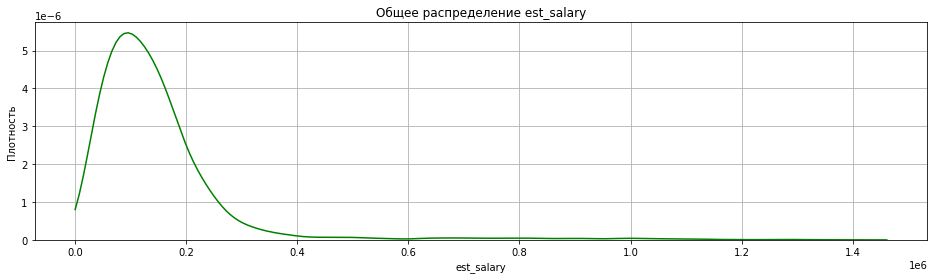

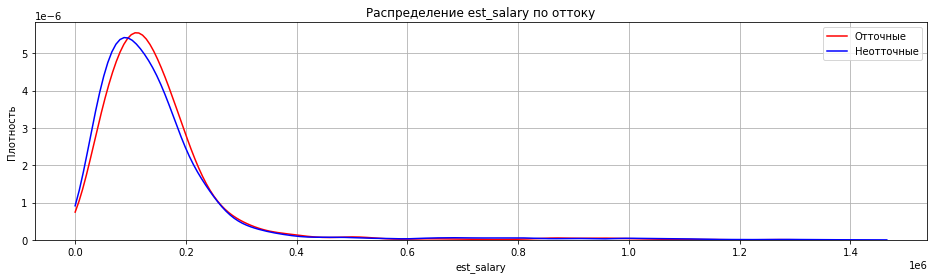

In [34]:
plot_feature_distributions(bank, 'est_salary')

<i> По распределению заработной платы клиентов банка можно сказать, что у большинства клиентов оценочный уровень дохода до 200.000 рублей. Пик находится в диапазоне примерно 100.000 рублей. В целом основная часть клиентов банка это клиенты с низким и средним доходами.  
    По графику отточности/неотточности видим, что клиенты с доходами а диапазоне до 200.000 рублей имееют высокий уровень отточности. Пик сдвинут слегка правее 100.000 рублей, в то время как у неотточных клиентов слегка левее.  
    Отметим, что клиенты с высоким доходом имеют меньшую вероятность ухода из банка.</i>

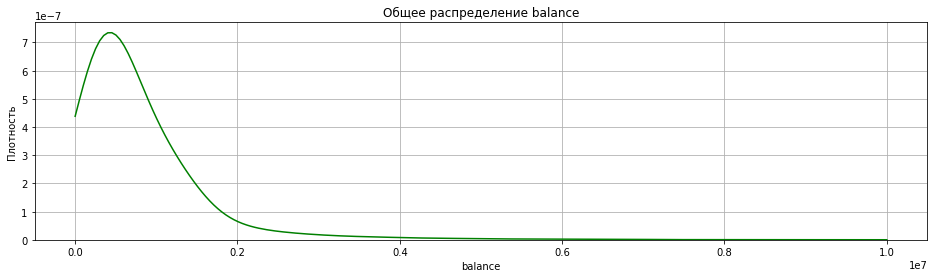

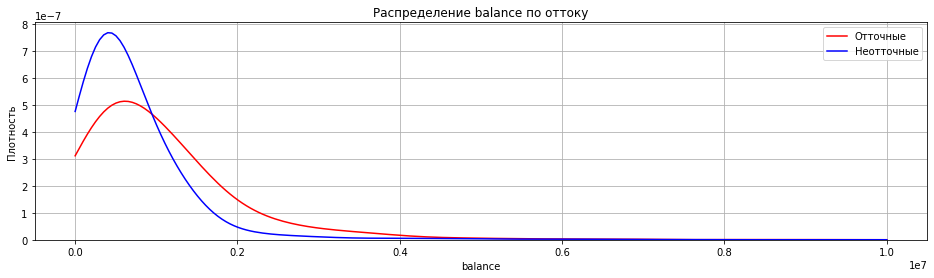

In [35]:
plot_feature_distributions(bank, 'balance')

<i> По общему графику можем сказать, что у большинства клиентов на балансе небольшие суммы. Клиентов банка с высоким балансом очень мало.   
    По графику отточности/неотточности видим, что оба пика приходятся так же на низкие балансы. Отметим только, что пик неотточных клиентов чуть выше пика отточных. У неотточных клиентов распределение более выраженное, хоть и балансы низкие у таких клиентов, но банк они не покидают. У отточных клиентов распределение более равномерное, что может означать о большем числе клиентов с более высокими балансами на счете.</i>

In [36]:
#  теперь зададим функцию для визуализации категориальных величин 
# (город, пол, продукты банка, используемые клиентами, количество баллов собственности и наличие кредитной карты)
def plot_categorical_distribution(bank, feature, figsize=(15, 4), churn_mean=None):
    fig, axes = plt.subplots(1, 3, figsize=figsize)

    # общее распределение
    sns.countplot(data=bank, x=feature, ax=axes[0], palette='gist_rainbow')
    axes[0].set_title(f'Общее распределение по {feature}')
    axes[0].set_ylabel('Количество')
    axes[0].grid(True)

    # распределение по оттоку (количество)
    sns.countplot(data=bank, x=feature, hue='churn', ax=axes[1], palette='gist_rainbow')
    axes[1].set_title(f'{feature} по оттоку')
    axes[1].set_ylabel('Количество')
    axes[1].legend(labels=['Неотточные', 'Отточные'])
    axes[1].grid(True)

    # распределение по оттоку (доли)
    churn_rate = (bank.groupby(feature)['churn']
                  .mean()
                  .reset_index())
    sns.barplot(data=churn_rate, x=feature, y='churn', palette='gist_rainbow', ax=axes[2])
    axes[2].set_title(f'Уровень оттока по {feature}')
    axes[2].set_ylabel('Доля отточных клиентов')
    axes[2].set_xlabel(feature)
    axes[2].set_ylim(0, 1)
    axes[2].grid(True)
    
    # Вычисляем средний уровень оттока если он не передан
    if churn_mean is None:
        churn_mean = bank['churn'].mean()
        
    # Добавляем линию среднего уровня оттока
    axes[2].axhline(churn_mean, color='red', linestyle='--', label=f'Средний уровень ({churn_mean:.2f})')
    
    # Добавляем текстовые метки для каждого столбца
    for index, row in churn_rate.iterrows():
        axes[2].text(index, row['churn'] + 0.02, f"{row['churn']:.2f}", ha='center')
        
    axes[2].legend()

    plt.tight_layout()
    plt.show()

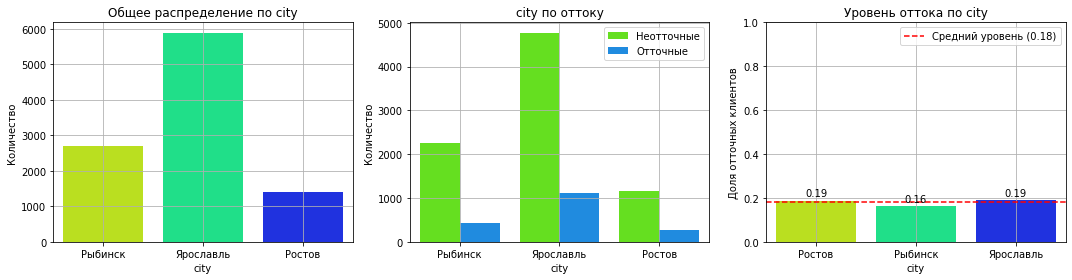

In [37]:
plot_categorical_distribution(bank, 'city')

<i> Больше всего клиентов банка находиятся в г. Ярославль, г. Ростов и г. Рыбинск имеют меньше клиентов, самы маленький по численности - г. Ростов.  
    В г. Ярославле и г. Ростове доля неотточных клиентов значительно превышает долю отточных, можно сказать, что там более стабильная клиентская база. В г. Рыбинске доля отточных клиентов чуть выше, в отличие от других городов, значит там более высокий уровень оттока клиентов.  
    Средний уровень оттока составляет 0.18, чуть выше этот показатель в г. Ростов и г. Ярославль - 0.19, самый низкий показатель в г. Рыбинске - 0.16.</i>

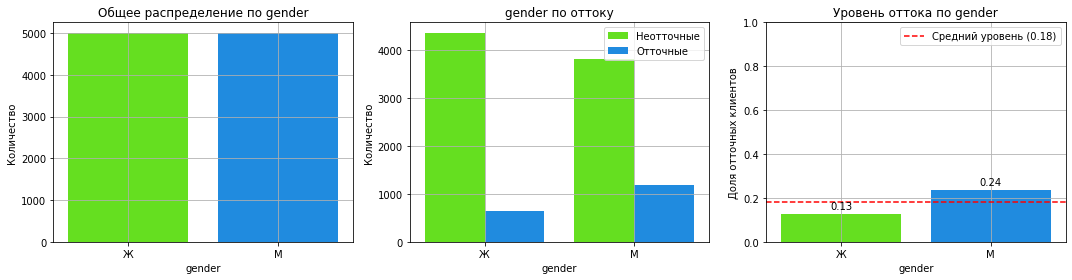

In [38]:
plot_categorical_distribution(bank, 'gender')

<i> Количество клиентов мужчин и женщин одинаково.  
    В обеих группах преобладают неотточные клиенты, но стоит отметить, что отточных клиентов мужчин почти в 2 больше чем отточных клиентов женщин.  
    Уровень оттока у женщин - 0.13, у мужчин - 0.24.</i>

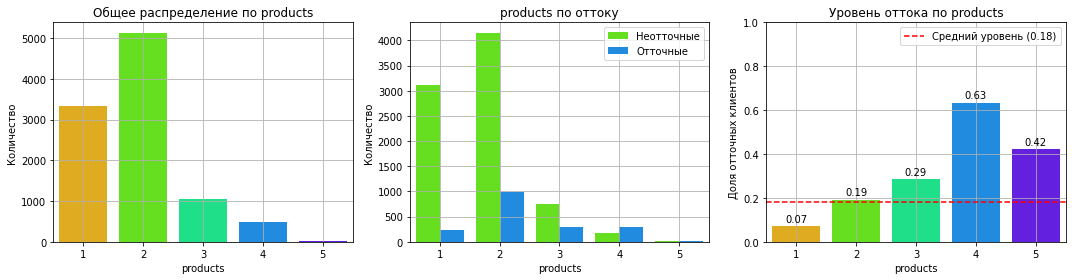

In [39]:
plot_categorical_distribution(bank, 'products')

<i> По графикам видим, что большинство клиентов используют 1-2 продукта банка. Меньше всего клиентов, которые пользуются 5-ью продуктами банка.  
    Самый низкий уровень оттока клиентов, которые используют 1 или 2 продукта банка. Отточные клиенты, использующие 4 продукта банка, превышают неотточных клиентов почти вдвое.  
    Самый высокий уровень отточности (0.63) среди клиентов, использующих 4 продукта банка, также высокие показатели у клиентов, использующих 5 продуктов банка (0.42) и использующих 3 прудкта банка (0.29). Самый низкий уровень у клиентов с 1-м продуктом банка (0.07), у клиентов с 2-мя продуктами показатель 0.29.</i>

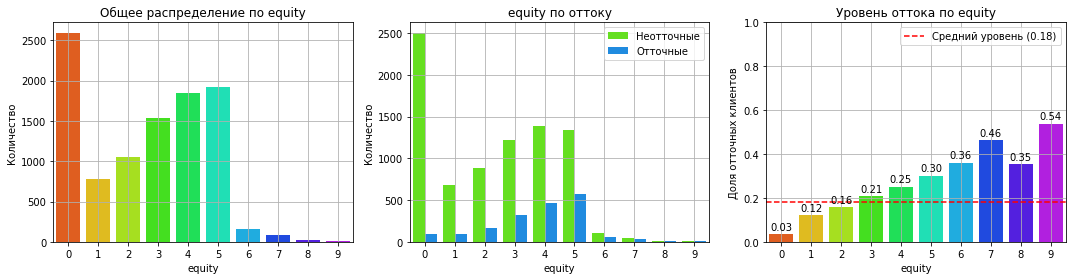

In [40]:
plot_categorical_distribution(bank, 'equity')

<i> По количеству баллов собственности можно сказать, что большинство клиентов банка не имеют ничего в собственности. Следующий показатель у клиентов с 5-ью баллами собственности, потом с 4-мя и так до 1 балла собственности. Малое количество клиентов от 6-ти баллов собствености и дальше, самое малое количество клиентов с 9-ью баллами собственности.  
    В целом неотточные клиенты в каждом балле собственности преобладают над отточными.  
    Самый маленький уровень отточности (0.03) у клиентов не имеющих собственности, затем идут клиенты с 1-м баллом собственности (0.12) и клиенты с 2-мя баллами собственности (0.16). Затем показатели уже выше среднего уровня. Самые высокие уровни отточности у клиентов с 9-ью баллами (0.54) и 7-ью баллами (0.46) собственности.</i>

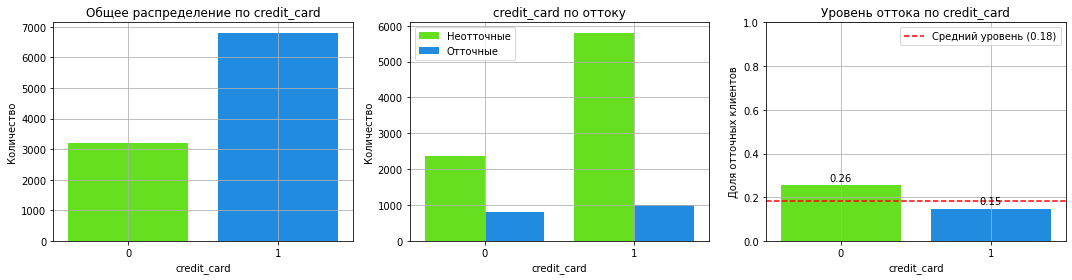

In [41]:
plot_categorical_distribution(bank, 'credit_card')

<i> В банке больше клиентов, имеющих кредитные карты, чем не имеющих почти в 2 раза.  
    Хоть таких клиентов и больше, доля оттока у них меньше (0.15), у отточных - 0.26.</i>

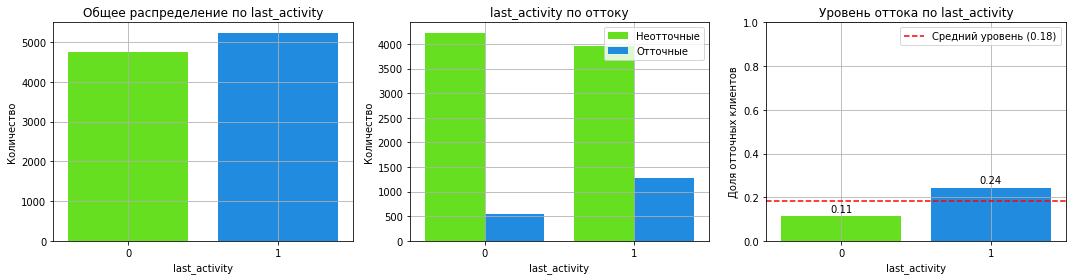

In [42]:
plot_categorical_distribution(bank, 'last_activity')

<i> Активные клиенты преобладают по численности, нежели неактивные. 
    Доля оттока у активных клиентов больше, чем у неактивных почти в два раза.  
    Уровень оттока у неактивных составляет 0.11, у активных - 0.24.</i>

<b>3.2. Корреляционный анализ.</b>
<a id='3.2'></a>

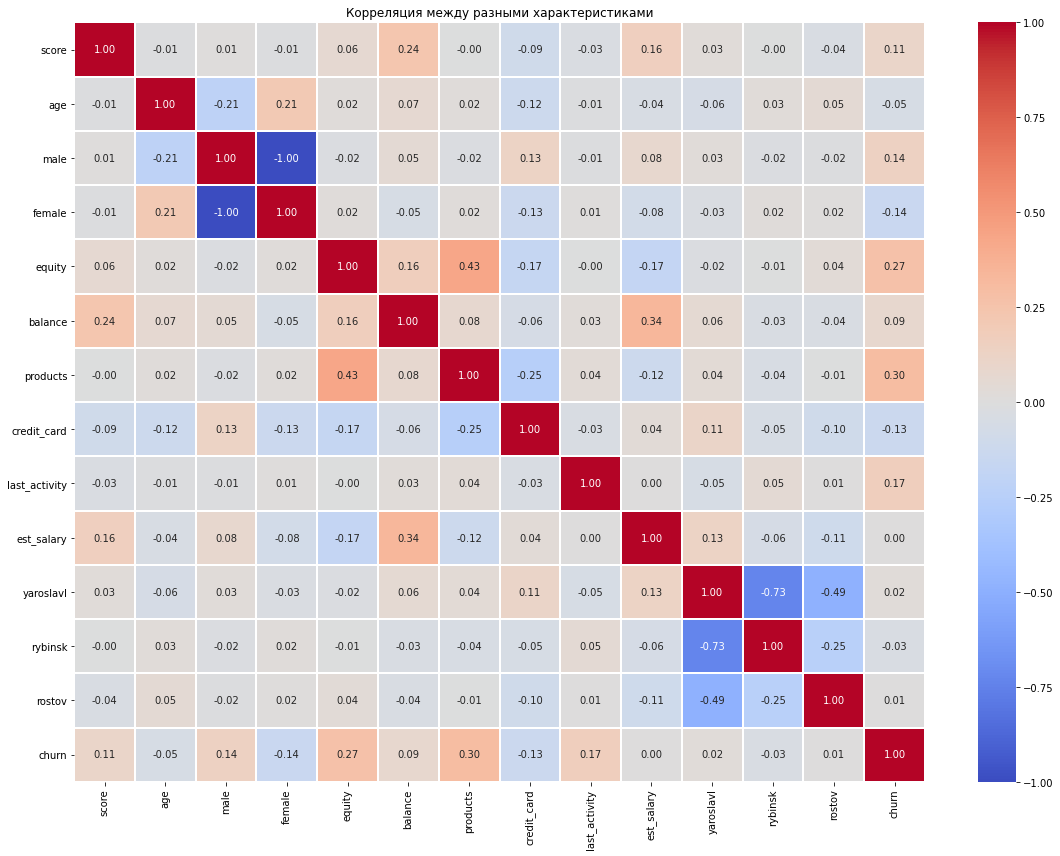

In [43]:
columns = bank[[
    'score', 'age', 'male', 'female', 'equity', 'balance',
    'products', 'credit_card', 'last_activity', 'est_salary',
    'yaroslavl', 'rybinsk', 'rostov', 'churn']
]

plt.figure(figsize=(16, 12))

sns.heatmap(
    columns.corr(),
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    annot=True,
    linewidths=1,
)

plt.title('Корреляция между разными характеристиками')

plt.tight_layout()
plt.show()

<i> Что можем сказать по нашей карте:  
    · что между городами Ярославлем, Ростовом и Рыбинском высокие отрицательные связи: Ярославль-Рыбинск -0.73, Ярославль-Ростов -0.49 и Ростов-Рыбинск -0.25, стоит обратить внимание;  
    · ожидаем результат по мужскому и женскому полу, так как человек не может немного этим и немного другим;   
    · видим положительную связь между балансом на счете и оценочным доходом клиента (0.34), что тоже логично;  
    · достаточно высокая положительная связь между баллами собственности клиента и его используемыми продуктами банка (0.43);  
    · стоит отметить что имеется положительная связь между показателем оттока и продуктами банка, используемые клиентами (0.3), а также с количеством баллов собственности клиента (0.27);  
    · остальные признаки имеют незначительные положительные или же отрицательные связи.</i>    

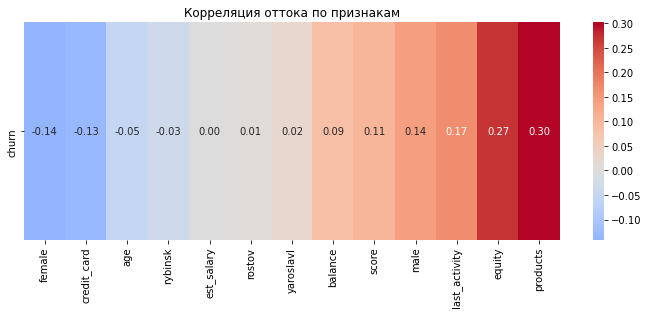

In [44]:
# построим чисто отсортированную тепловую карту взаимосвязей с оттоком
corr_matrix = columns.corr()
corr_with_churn = corr_matrix['churn'].drop('churn')
sorted_corr = corr_with_churn.sort_values()

sorted_corr_df = sorted_corr.to_frame().T # фрейм для тепловой карты

# смотрим
plt.figure(figsize=(12, 4))
sns.heatmap(
    sorted_corr_df,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    center=0
)
plt.title('Корреляция оттока по признакам')
plt.show()

<i> По отсортированной тепловой карте мы видим, что умеренная положительная связь оттка связана с числом продуктов банка, используемых клиентами (0.30). Также положительная связь есть у оттока с количетсвом баллов собственности клиентов (0.27), с активностью клиентов (0.17), с мужским полом (0.14), с баллами кредитного скорринга (0.11), слабая положительная связь также есть с балансом влиентов (0.09), с городами Ярославлем (0.02) и Ростовом (0.01). Полное отсутствие связи оттока с оценочным доходом клиентов. Слабая отрицательная связь оттока наблюдается с городом Рыбинск (-0.03) и возрастом клиентов (-0.05). И уже то же не сильная отрицательная связь есть с наличием кредитных карт у клиентов (-0.13) и клиентов женского пола (-0.14). </i>

<b>3.3. Составление и проверка гипотез.</b>
<a id='3.3'></a>

<b>3.3.1. Гипотеза 1: Среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших клиентов равно. </b>
<a id='3.3.1'></a>

в данном случае будем использовать t-тест для независимых выборок.
у нас большие выборки, подходит для анализа различий в средних значениях между двумя независимыми наборами данных, этот тест позволит определить, есть ли статистически значимая разница между средними двух групп. 
альтернативная гипотеза может быть проверена тремя вариантами "меньше", "не равно", "больше" необходимо проверить вопрос про равенство, следовательно проверку надо провести двухстороннюю alternative='two-sided'.

<i>Основная и альтернативная гипотезы:</i>

<b>Н0:</b> Среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших клиентов равно.  
<b>Н1:</b> Среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших клиентов различается.

In [45]:
alpha = 0.05

print('Среднее количество продуктов банка у ушедших клиентов: ', round((bank[bank['churn'] == 1]['products']).mean(),2))
print('Среднее количество продуктов банка у оставшихся клиентов: ', round((bank[bank['churn'] == 0]['products']).mean(),2))

results = st.ttest_ind(
    bank[bank['churn'] == 1]['products'], 
    bank[bank['churn'] == 0]['products'],
    equal_var = False, 
    alternative='two-sided'
)
    
print('P-значение: ', results.pvalue)
    
if (results.pvalue < alpha):
    print("Отвергаем нулевую гипотезу, среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших не равно.")
else:
    print("Не получилось отвергнуть нулевую гипотезу, среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших равно")

Среднее количество продуктов банка у ушедших клиентов:  2.38
Среднее количество продуктов банка у оставшихся клиентов:  1.76
P-значение:  3.241238337429691e-139
Отвергаем нулевую гипотезу, среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших не равно.


<i> Р-значение слишком маленькое, значительно меньше критического уровня статистической значимости, по-этому мы отвергаем нулевую гипотезу о равенстве в количестве используемых продуктов банка среди оставшихся и ушедших клиентов.  
    У ушедших клиентов в среднем больше продуктов банка, которые они использовали, по сравнению с оставшимися.  
    Отметим, что клиенты с большим количество используемых продуктов банка связаны с риском ухода из банка.</i>

<b>3.3.2. Гипотеза 2: Распределение пола среди ушедших и оставшихся клиентов независимо. </b>
<a id='3.3.2'></a>

в данном случаем будем использовать Хи-квадрат тест, так как мы проверяем две категориальные переменные, это лучший выбор для проверки независимости этих величин.

<i>Основная и альтернативная гипотезы:</i>

<b>Н0:</b> Распределение пола среди ушедших и оставшихся клиентов независимо.  
<b>Н1:</b> Распределение пола среди ушедших и оставшихся клиентов зависит.

In [46]:
alpha = 0.05

contingency_table = pd.crosstab(bank['gender'], bank['churn'])
print(contingency_table)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f'Значение хи-квадрат: {chi2}')
print(f'Р-значение: {p_value}')

if p_value < alpha:
    print("Отвергаем нулевую гипотезу, есть статистически значимая разница в распределении пола среди уцшедших и оставшихся клиентов банка")
else:
    print("Не получилось отвергнуть нулевую гипотезу, нет статистически значимой разницы в распределении пола между ушедшими и оставшимися клиентами.")

churn      0     1
gender            
Ж       4358   636
М       3822  1183
Значение хи-квадрат: 198.8690202431055
Р-значение: 3.686722178673345e-45
Отвергаем нулевую гипотезу, есть статистически значимая разница в распределении пола среди уцшедших и оставшихся клиентов банка


<i> Р-значение слишком маленькое, значительно меньше критического уровня статистической значимости, по-этому мы отвергаем нулевую гипотезу о независимости распределения пола среди ушедших и оставшихся клиентов банка.  
    Среди женщин остались 4.358, ушли - 636, а среди мужчин остались 3.822, в то время как ушли 1.183.  
Значит пол влияет на вероятность ухода клиента. В данном случае, судя по числам, у мужчин доля уходящих выше, чем у женщин.</i>

<b>3.4. Промежуточные выводы.</b>
<a id='3.4'></a>

<i> Мы провели исследовательский анализ данных для дальнейшей сегментации клиентов банка. Теперь следует все обобщить:  
    1. При анализе распределения признаков, в том числе в разрезе оттока, мы установили, что процент отточных клиентов составляет 18.19%. Установили, что в диапазоне примерно от 820 до 900 баллов кредитного скоринга у нас преобладают отточные клиенты. Большинству отточных клиентов банка от 30 до 40 лет и от 50 до 60 лет. Клиенты с доходами а диапазоне до 200.000 рублей имееют высокий уровень отточности. Баланс в среднем миллион. Из крупных городов, например г. Ярославль. Больше отточныз клиентов среди мужчин. У отточных клиентов в основном было много продуктов банка (начиная с 3-х и выше). У отточных больше баллов собственности, чем не у отточных (от 3-х и выше). У отточных клиентов вероятнее нет кредитных карт. Отточные клиенты достаточно активны в последние 90 дней, возможно активность как раз тесно связана с уходом из банка.  
    2. При корреляции установили, что умеренная положительная связь оттка связана с числом продуктов банка, используемых клиентами (0.30). Также положительная связь есть у оттока с количетсвом баллов собственности клиентов (0.27), с активностью клиентов (0.17), с мужским полом (0.14), с баллами кредитного скорринга (0.11), слабая положительная связь также есть с балансом влиентов (0.09), с городами Ярославлем (0.02) и Ростовом (0.01). Полное отсутствие связи оттока с оценочным доходом клиентов. Слабая отрицательная связь оттока наблюдается с городом Рыбинск (-0.03) и возрастом клиентов (-0.05). И уже то же не сильная отрицательная связь есть с наличием кредитных карт у клиентов (-0.13) и клиентов женского пола (-0.14).  
    3. И проверили 2 гипотезы. В первой гипотезе проверили, что у ушедших клиентов в среднем больше продуктов банка, которые они использовали, по сравнению с оставшимися и отметим, что клиенты с большим количество используемых продуктов банка связаны с риском ухода из банка. Во второй установили, что гендерное распределение влияет на вероятность ухода из банка, в нашем случае банк покидают чаще мужчины.  
    
    На основании этого, сделаем грубый портрет отточного клиента:
    
<b> МУЖЧИНА ИЗ КРУПНОГО ГОРОДА (г. Ярославль) В ВОЗРАСТЕ ОТ 30-ти ДО 40-ка ИЛИ ОТ 50-ти ДО 60-ти ЛЕТ. НЕ ИМЕЕТ КРЕДИТНОЙ КАРТЫ, В ТЕЧЕНИЕ 90 ДНЕЙ ДОСТАТОЧНО АКТИВНЫЙ КЛИЕНТ. У НЕГО НЕСКОЛЬКО ПРОДУКТОВ БАНКА (больше 3-х), В СОБСТВЕННОСТИ НЕСКОЛЬКО ЕДИНИЦ (от 3-х). НА БАЛАНСЕ У НЕГО СУММА ОКОЛО МИЛЛИОНА И ВЫШЕ, А ТАКЖЕ ЕГО ЗАРПЛАТА 200.000 РУБЛЕЙ. ЕГО БАЛЛЫ КРЕДИТНОГО СКОРИНГА В ДИАПОЗОНЕ ОТ 820 ДО 900.</b>

<h1>4. Сегментация отточных клиентов банка.</h1>
<a id='4'></a>

In [47]:
# создадим список по нашем портрету отточного клиента
c=[ 
    'male == 1',
    'equity >= 3',
    'credit_card == 0',
    'last_activity == 1',
    '150000 <= est_salary <= 200000',
    '30 <= age <= 40',
    '50 <= age <= 60',
    '820 <= score <= 900',
    'balance > 900000'
]

In [48]:
# общее количество и уровень оттока по банку
churn_count = bank['churn'].sum()
churn_rate = bank['churn'].mean()
print('Количество отточных клиентов по банку:', churn_count)
print('Уровень оттока по банку:', round(churn_rate * 100, 2), '%')

def query_concat(a, op=' and '):
    q = ''
    for i in a:
        if i != '':
            q = i if q == '' else q + op + i
    return q

def query_concat_2(a):
    q = ''
    for i in a:
        if i != '':
            q = '(' + i if q == '' else q + ') or (' + i
    return q + ')'

def query_churn_mean(q):
    if q == '':
        return 0
    seg = bank.query(q)
    count = len(seg)
    if count < 500 or count > 5000:
        return 0
    mean_churn = seg['churn'].mean()
    return round(mean_churn, 2)

# переберем значения
best_k = -1
best_q = ''

indices = list(range(len(c)))

for x in indices:
    for y in indices:
        for z in indices:
            if len({x, y, z}) < 3: # чтобы не было повторений
                continue

            # условия для сегментов
            seg1 = query_concat([c[x], c[y], c[z]])
            seg2 = query_concat([c[x], c[y], c[z]])
            seg3 = query_concat([c[x], c[y], c[z]])

            # уровень оттока для каждого сегмента
            q1_k = query_churn_mean(seg1)
            q2_k = query_churn_mean(seg2)
            q3_k = query_churn_mean(seg3)

            # проверим условия высокого уровня оттока
            if (q1_k > 2 * churn_rate) and (q2_k > 2 * churn_rate) and (q3_k > 2 * churn_rate):
                combined_q = query_concat_2([seg1, seg2, seg3])
                t_k = query_churn_mean(combined_q)
                if t_k > best_k:
                    best_k = t_k
                    best_q = combined_q
                    print(f"Уровень оттока сегмента {best_k}")
                    print(f"Условия:\n{best_q}")
                    print(f"Количество клиентов: {len(bank.query(best_q))}\n")

Количество отточных клиентов по банку: 1819
Уровень оттока по банку: 18.19 %
Уровень оттока сегмента 0.47
Условия:
(male == 1 and equity >= 3 and credit_card == 0) or (male == 1 and equity >= 3 and credit_card == 0) or (male == 1 and equity >= 3 and credit_card == 0)
Количество клиентов: 891

Уровень оттока сегмента 0.49
Условия:
(male == 1 and equity >= 3 and balance > 900000) or (male == 1 and equity >= 3 and balance > 900000) or (male == 1 and equity >= 3 and balance > 900000)
Количество клиентов: 1031

Уровень оттока сегмента 0.61
Условия:
(male == 1 and last_activity == 1 and balance > 900000) or (male == 1 and last_activity == 1 and balance > 900000) or (male == 1 and last_activity == 1 and balance > 900000)
Количество клиентов: 581



<i> <b>Сегмент 1</b> - клиенты мужчины без кредитных карт с высоким количеством баллов собственности, начиная с 3-х;   
    <b>Сегмент 2</b> - клиенты мужчины с балансом на счете больше 900.000 рублей и с высоким количеством баллов собственности, начиная с 3-х;  
    <b>Сегмент 3</b> - активные клиенты мужчины с балансом на счете больше 900.000 рублей.</i>

In [49]:
seg1 = bank.query('male == 1 and equity >= 3 and credit_card == 0')
seg2 = bank.query('male == 1 and equity >= 3 and balance > 900000')
seg3 = bank.query('male == 1 and balance > 900000 and last_activity == 1')

In [50]:
display(seg1.head())
display(seg1.describe())

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
18,136651,876,Ярославль,М,40,5,2307947.36,2,0,0,287010.61,0,0,0,0,1,0,1
20,114192,772,Ростов,М,43,3,1315511.65,2,0,0,143935.71,0,0,1,0,0,0,1
35,221927,863,Ростов,М,39,5,1461423.33,1,0,1,221699.52,0,0,1,0,0,0,1
72,156677,873,Ярославль,М,39,5,915959.85,3,0,1,154034.62,1,0,0,0,1,0,1
81,223978,850,Рыбинск,М,34,5,351583.16,4,0,1,115354.97,1,0,0,1,0,0,1


,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,174308.74,865.16,41.74,4.39,1413276.94,2.35,0.00,0.56,155018.51,0.47,0.00,0.20,0.30,0.51,0.00,1.00
std,35128.68,53.60,10.96,1.01,2286740.35,0.69,0.00,0.50,139243.27,0.50,0.00,0.40,0.46,0.50,0.00,0.00
min,96562.00,724.00,18.00,3.00,45.00,1.00,0.00,0.00,9766.13,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,146543.50,828.50,33.00,4.00,507548.78,2.00,0.00,0.00,81720.68,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,174009.00,868.00,40.00,4.00,951843.84,2.00,0.00,1.00,128656.24,0.00,0.00,0.00,0.00,1.00,0.00,1.00
75%,206464.00,903.00,50.50,5.00,1510385.43,3.00,0.00,1.00,183064.01,1.00,0.00,0.00,1.00,1.00,0.00,1.00
max,229058.00,1000.00,74.00,9.00,43277099.84,4.00,0.00,1.00,1395064.45,1.00,0.00,1.00,1.00,1.00,0.00,1.00


<i> <b> Портрет клиента сегмента 1:</b>  
    - мужчина;  
    - средний возраст около 42 лет;  
    - большое колличество баллов собственности (от 4-х);  
    - баланс на счете больше 1.000.000 рублей;  
    - в среднем использует 2-3 продукта банка;  
    - не имеет кредитных карт;  
    - более менее активный клиент;  
    - заработная платная в среднем около 155.000 рублей.<i>

In [51]:
display(seg2.head())
display(seg2.describe())

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
8,211686,923,Ярославль,М,54,5,1206337.87,2,1,0,155371.79,0,0,0,0,1,0,1
15,120260,731,Рыбинск,М,42,3,1480548.47,3,1,0,160974.43,0,0,0,1,0,0,1
18,136651,876,Ярославль,М,40,5,2307947.36,2,0,0,287010.61,0,0,0,0,1,0,1
20,114192,772,Ростов,М,43,3,1315511.65,2,0,0,143935.71,0,0,1,0,0,0,1
35,221927,863,Ростов,М,39,5,1461423.33,1,0,1,221699.52,0,0,1,0,0,0,1


,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
count,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00,1031.00
mean,176922.28,878.76,43.03,4.40,2239512.68,2.32,0.55,0.53,197218.96,0.49,0.00,0.13,0.25,0.62,0.00,1.00
std,35185.02,53.25,9.88,0.91,4880375.01,0.87,0.50,0.50,176276.90,0.50,0.00,0.34,0.43,0.49,0.00,0.00
min,96562.00,727.00,23.00,3.00,901028.81,1.00,0.00,0.00,21765.76,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,148746.50,840.00,35.00,4.00,1132539.05,2.00,0.00,0.00,108581.30,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,178967.00,886.00,41.00,5.00,1375872.86,2.00,1.00,1.00,154671.70,0.00,0.00,0.00,0.00,1.00,0.00,1.00
75%,210105.00,916.00,51.00,5.00,2042317.00,3.00,1.00,1.00,214310.72,1.00,0.00,0.00,0.00,1.00,0.00,1.00
max,229058.00,1000.00,74.00,9.00,119113552.01,5.00,1.00,1.00,1395064.45,1.00,0.00,1.00,1.00,1.00,0.00,1.00


<i> <b> Портрет клиента сегмента 2:</b>  
    - мужчина;  
    - средний возраст около 43 лет;  
    - большое колличество баллов собственности (от 4-х);  
    - большая сумма на балансе счета (в среднем более 2.200.000 рублей);  
    - в среднем использует 2-3 продукта банка;  
    - вероятнее имеет кредитную карту банка;  
    - более менее активный клиент;  
    - заработная платная в среднем около 200.000 рублей.<i>

In [52]:
display(seg3.head())
display(seg3.describe())

,userid,score,city,gender,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
35,221927,863,Ростов,М,39,5,1461423.33,1,0,1,221699.52,0,0,1,0,0,0,1
36,199614,822,Ярославль,М,60,5,1472483.77,1,1,1,89132.67,0,0,0,0,1,0,1
72,156677,873,Ярославль,М,39,5,915959.85,3,0,1,154034.62,1,0,0,0,1,0,1
77,191976,937,Ярославль,М,33,5,2061152.96,2,1,1,280670.62,1,0,0,0,1,0,1
79,191348,768,Ярославль,М,36,4,963460.20,2,1,1,120197.47,0,0,0,0,1,0,1


,userid,score,age,equity,balance,products,credit_card,last_activity,est_salary,churn,missing_balance,rostov,rybinsk,yaroslavl,female,male
count,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00,581.00
mean,177356.50,872.99,42.81,4.25,2442996.90,2.36,0.53,1.00,199691.09,0.61,0.00,0.13,0.28,0.59,0.00,1.00
std,34795.14,56.67,10.06,1.17,6262737.61,0.89,0.50,0.00,186740.05,0.49,0.00,0.33,0.45,0.49,0.00,0.00
min,97927.00,727.00,23.00,0.00,901028.81,1.00,0.00,1.00,21765.76,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,150424.00,834.00,35.00,4.00,1124593.53,2.00,0.00,1.00,107237.18,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,178169.00,877.00,41.00,4.00,1348049.29,2.00,1.00,1.00,150197.79,1.00,0.00,0.00,0.00,1.00,0.00,1.00
75%,208738.00,913.00,51.00,5.00,1995160.41,3.00,1.00,1.00,208710.01,1.00,0.00,0.00,1.00,1.00,0.00,1.00
max,229058.00,1000.00,69.00,9.00,119113552.01,5.00,1.00,1.00,1395064.45,1.00,0.00,1.00,1.00,1.00,0.00,1.00


<i> <b> Портрет клиента сегмента 3:</b>  
    - мужчина;  
    - средний возраст около 43 лет;  
    - большое колличество баллов собственности (от 4-х);  
    - большая сумма на балансе счета (в среднем около 2.500.000 рублей);  
    - в среднем использует 2-3 продукта банка;  
    - вероятнее имеет кредитную карту банка;  
    - активный клиент;  
    - заработная платная в среднем около 200.000 рублей.<i>

<b>4.1. Приортизация сегментов клиентов банка.</b>
<a id='4.1'></a>

<i> Что стоит отметить:  
    1. Самый высокий уровень оттока у 3-го сегмента (0.61), самый низкий у 1-го (0.47);
    2. Большой размер сегмента 2 (1031 клиент);  
    3. Каждый сегмент в среднем использует 2-3 продукта банка;  
    4. В каждом сегменте у клиентов большое количество баллов собственности (от 4-х);  
    5. Большие суммы на балансе у 3-го сегмента (в среднем около 2.500.000 рублей);  
    6. Высокие зарабатные платы (около 200.000 рублей) у 2-го и 3-го сегментов.  
    
Приортизировать сегменты стоит так:  
    
    
<b>1 приоритет</b> - сегмент 3 (уровень оттока 0.61 - самый высокий), удержание клиентов этого сегмента поможет существенно снизить общий показатель оттока, так же отметим, что у клиентов этого банка много собственности, большие суммы на счете, высокая заработная плата, а также они пользуются несколькими продуктами банка - это важные клиенты для банка! 
    
<b>2 приоритет</b> - сегмент 2 (уровень оттока 0.49), хоть уровень оттока ниже почти на 12 единиц в сравнении с сегментом 3, но таких клиентов больше по количеству (1031 клиент - больше всего), самый крупный, и клиенты важны для банка, так как у них тоже много собственности, большие суммы на счете, высокая заработная плата, используют несколько продуктов банка! 
    
И уже <b>3 приоритет</b> - сегмент 1 (уровень оттока 0.47).</i>  

<h1>5. Заключительный вывод. Рекомендации.</h1>
<a id='5'></a>

<b> 1. Мы получили данные о клиентах регионального банка "Метанпромбанк" в файле "bank_scrooge.csv" и изучили его.</b>  

Данные представляют собой таблицу из 10.000 строк и 12 стобцов:

+ идентификатор пользователя;
+ баллы кредитного скорринга;
+ город проживания клиента;
+ пол клиента;
+ возраст клиента;
+ количество баллов собственности клиента;
+ баланс счета клиента;
+ количество продуктов, которыми пользуется клиент;
+ наличие кредитной карты у клиента;
+ активность клиента;
+ оценочный доход клиента (зарабатная плата);
+ признак оттока.  

Обнаружили ряд проблем: 
+ со стилизацией столбцов таблицы;
+ наличие пропусков в столбцах возраста и баллов кредитного скоринга;  
+ непорядок с типом данных в столбцах баллов кредитного скорринга и возраста.

<b> 2. Подготовили полученные данные для дальнейшего исследования. </b>

2.1. Привели названия столбцов в нашей таблице к нижнему регистру.

2.2. В двух столбцах обнаружили пропуски.  
Перед этим добавили 5 стобцов для удобства анализа: 3 города - Ярославль, Ростов и Рыбинск, а также 2 столбца с гендерным распределением на мужской и женский пол.  

+ Столбец с возростами клиентов. Пропусков в этом столбце не так много, всего 26, что составляет 0.26% от общего числа строк в данном столбце. Они не связаны с какой-либо конкретной характеристикой. Такие пропуски можно отнести к MCAR по общепринятой классификации пропусков (MCAR (Missing Completely At Random / Отсутствует совершенно случайно) — пропуски не зависят от переменных и не ведут к   систематической ошибке (смещение, bias), но увеличивают случайную ошибку (разброс, variance), можно их отбрасывать или   заполнять, т.к. заполнение не повлияет на характер связи между заполняемой переменной и остальными.). Заполнили такие пропуски медианными значениями;  
+ Столбец с балансами клиентов. В данном столбце 2.294 пропуска, что составляет 22.94% от общего числа строк данного столбца. После проведения анализа установили, что между отсутствием баланса и баллами собственности имеется высокая отрицательная корреляция (-0.71), также высокая отрицательная корреляция (-0.49) баланса есть с количеством продуктов банка, что первый случай, что второй может быть аргументирован покупкой крупного имущества (движимого и недвижимого). Пропуски в балансе на счете клиентов можно отнести к MNAR по общепринятой классификации пропусков (MNAR (Missing Not At Random / Отсутствует не случайно) — пропуски зависят от данных, без дополнительного обоснования их нельзя отбрасывать или заполнять одним значением, т.к. это приведёт к заметным искажениям.). Мы оставили эти пропуски без изменений.

2.3. В столбцах баллов кредитного скоринга и возраста поменяли тип данных на целочисленный (int).  

2.4. Проверили данные на наличие дубликатов. Хоть и явных не выявили, но обнаружили 73 неявных дубликата. При проверке этих дубликатов было выявлено, что клиентам из разных городов просто присвоили один и тот же идентификатор пользователя - неправильный сбор информации, но все эти люди разные. Такие дубликаты мы оставили для дальнейшго исследования.  

<b> 3. Исследовательский анализ данных (EDA).</b>  

3.1. Провели анализ распределения признаков, в том числе в разрезе оттока.  

Установили, что отточные клиенты составляют у нас 18.19% (1.819 клиентов) от общего числа клиентов банка.  
При рассмотрении тенденций в разрере оттока получили:  
+ баланс на счете - у отточных клиентов больше, чем у неотточных (относительная разница 0.65);  
+ баллы собственности - у отточных клиентов больше, чем у неотточных (относительная разница 0.59);  
+ активность - по последним 90 дня отточные клиенты более активны, чем неотточные (относительная разница 0.45);  
+ продукты банка - больше пользуются отточные клиенты )относительная разница (0.39);  
+ заработная плата - у отточных выше, чем у неотточных (относительная разница (0.06);  
+ баллы кредитного скоринга - выше у отточных, чем у неотточных (0.02);  
+ возраст - средний возраст у отточных 39 лет, у неотточных - 40 лет (относительная разница -0.03);  
+ наличие кредитных карт - неотточные больше пользуются картами, нежели отточные (относительная разница -0.22);  
+ мужчины - больше отточных, чем неотточных (относительная разница 0.39);  
+ женщины - неотточных больше чем отточных (относительная разница (-0.34);  
+ г. Ярославль - больше отточных, чем неотточных (относительная разница 0.05);  
+ г. Ростов - больше отточных, чем неотточных (относительная разница 0.39); 
+ г. Рыбинск - неотточных больше, чем отточных (относительная разница -0.13).

3.2. Провели корреляционный анализ. 
Установили, что умеренная положительная связь оттока связана с числом продуктов банка, используемых клиентами (0.30). Также положительная связь есть у оттока с количетсвом баллов собственности клиентов (0.27), с активностью клиентов (0.17), с мужским полом (0.14), с баллами кредитного скорринга (0.11), слабая положительная связь также есть с балансом влиентов (0.09), с городами Ярославлем (0.02) и Ростовом (0.01). Полное отсутствие связи оттока с оценочным доходом клиентов. Слабая отрицательная связь оттока наблюдается с городом Рыбинск (-0.03) и возрастом клиентов (-0.05). И уже то же не сильная отрицательная связь есть с наличием кредитных карт у клиентов (-0.13) и клиентов женского пола (-0.14).

3.3. Проверили 2 гипотезы. 

3.3.1. Гипотеза 1: Среднее количество продуктов банка, используемых клиентами, среди оставшихся и ушедших клиентов равно.  
Сделали вывод, что у ушедших клиентов в среднем больше продуктов банка, которые они использовали, по сравнению с оставшимися.  

3.3.2. Гипотеза 2: Распределение пола среди ушедших и оставшихся клиентов независимо.  
Сделали вывод, что пол влияет на вероятность ухода клиента, у мужчин доля уходящих выше, чем у женщин.

Сделали портрет отточного клиента для дальнейшейц сегментации: МУЖЧИНА ИЗ КРУПНОГО ГОРОДА (г. Ярославль) В ВОЗРАСТЕ ОТ 30-ти ДО 40-ка ИЛИ ОТ 50-ти ДО 60-ти ЛЕТ. НЕ ИМЕЕТ КРЕДИТНОЙ КАРТЫ, В ТЕЧЕНИЕ 90 ДНЕЙ ДОСТАТОЧНО АКТИВНЫЙ КЛИЕНТ. У НЕГО НЕСКОЛЬКО ПРОДУКТОВ БАНКА (больше 3-х), В СОБСТВЕННОСТИ НЕСКОЛЬКО ЕДИНИЦ (от 3-х). НА БАЛАНСЕ У НЕГО СУММА ОКОЛО МИЛЛИОНА И ВЫШЕ, А ТАКЖЕ ЕГО ЗАРПЛАТА 200.000 РУБЛЕЙ. ЕГО БАЛЛЫ КРЕДИТНОГО СКОРИНГА В ДИАПОЗОНЕ ОТ 820 ДО 900.

<b> 4. Сегментация отточных клиентов банка </b>  
Разделили отточных клиентов на 3 сегмента:  
Сегмент 1 - клиенты мужчины без кредитных карт с высоким количеством баллов собственности, начиная с 3-х;  
Сегмент 2 - клиенты мужчины с балансом на счете больше 900.000 рублей и с высоким количеством баллов собственности, начиная с 3-х;  
Сегмент 3 - активные клиенты мужчины с балансом на счете больше 900.000 рублей.  

И составили для каждого сегмента портреты:  

Портрет клиента сегмента 1:
- мужчина;
- средний возраст около 42 лет;
- большое колличество баллов собственности (от 4-х);
- баланс на счете больше 1.000.000 рублей;
- в среднем использует 2-3 продукта банка;
- не имеет кредитных карт;
- более менее активный клиент;
- заработная платная в среднем около 155.000 рублей.  

Портрет клиента сегмента 2:
- мужчина;
- средний возраст около 43 лет;
- большое колличество баллов собственности (от 4-х);
- большая сумма на балансе счета (в среднем более 2.200.000 рублей);
- в среднем использует 2-3 продукта банка;
- вероятнее имеет кредитную карту банка;
- более менее активный клиент;
- заработная платная в среднем около 200.000 рублей.  

Портрет клиента сегмента 3:
- мужчина;
- средний возраст около 43 лет;
- большое колличество баллов собственности (от 4-х);
- большая сумма на балансе счета (в среднем около 2.500.000 рублей);
- в среднем использует 2-3 продукта банка;
- вероятнее имеет кредитную карту банка;
- активный клиент;
- заработная платная в среднем около 200.000 рублей.

4.1. Приортизиция сегментов отточных клиентов банка.

1 приоритет - сегмент 3 (уровень оттока 0.61 - самый высокий), удержание клиентов этого сегмента поможет существенно снизить общий показатель оттока, так же отметим, что у клиентов этого банка много собственности, большие суммы на счете, высокая заработная плата, а также они пользуются несколькими продуктами банка - это важные клиенты для банка!

2 приоритет - сегмент 2 (уровень оттока 0.49), хоть уровень оттока ниже почти на 12 единиц в сравнении с сегментом 3, но таких клиентов больше по количеству (1031 клиент - больше всего), самый крупный, и клиенты важны для банка, так как у них тоже много собственности, большие суммы на счете, высокая заработная плата, используют несколько продуктов банка!

И уже 3 приоритет - сегмент 1 (уровень оттока 0.47).

<b>5. Рекомендации.</b>  
Приортизирая сегменты, как уже говорилось, на первое место лучше ставить сегмент 3, так как именно в нем самая большая доля оттока клиентов, затем сегмент 2 с самым большим количеством клиентов, и уже потом проработать сегмент 1. 

В 3-мм сегменте у нас мужчины с хорошей заработной платой, с большим балансом на счете и с большим количеством баллов собственности. Хоть клиенты этого сегмента и пользуются несколькими продуктами банка, следует все-равно прорекламировать другие продукты, например сделать упор на страховках имущества, инвестиции в фонды недвижимости, кредиты и другое.

Во 2-ом сегменте у нас также клиенты с хорошей заработной платой, с хорошим балансом на счете и с большим количеством баллов собственности. Хоть клиенты этого сегмента и пользуются несколькими продуктами банка, следует все-равно прорекламировать другие продукты, например сделать упор на страховках имущества, инвестиции в фонды недвижимости, кредиты и другое. То же, что и для сегмента 3.

В 1-ом сегменте у нас клиенты со средним достатком, но также с неплохим балансом на счете, большим количеством баллов собственности, но не имеющие кредитных карт банка. Стоит акценировать внимание на кредитовании для таких клиентов, предлагать выгодные условия, ставки.

5.1. Ссылка на презентацию: 